In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
from probjax.nn.layers.attention import flex_attention, dot_product_attention, BlockSizes
from probjax.nn.nets import Transformer
from probjax.utils.bmutil import benchmark
import jax.numpy as jnp
import jax

from flax import nnx
from functools import partial
from probjax.utils.bmutil import benchmark

from probjax.nn.pallas_kernels.flash_attention import flash_attention
from probjax.nn.pallas_kernels.attention import mha

In [5]:
import jax
import jax.numpy as jnp
seq_len = 512
q = jax.random.normal(jax.random.PRNGKey(0), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
k = jax.random.normal(jax.random.PRNGKey(1), (1,seq_len, 8, 64), dtype=jnp.bfloat16)
v = jax.random.normal(jax.random.PRNGKey(2), (1,seq_len, 8, 64), dtype=jnp.bfloat16)

In [6]:
attn_fn = jax.jit(partial(dot_product_attention, dtype=jnp.float32))
out1 = attn_fn(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32))

In [7]:
_ = benchmark(attn_fn, q, k, v)

CPU Utilization: 51% +/- 6%
Memory Utilization: 2% +/- 0%
Average time taken: 3.00 ms


In [8]:
import math
attn_fn = jax.jit(partial(flex_attention, sm_scale=1. / math.sqrt(64)))
out2 = attn_fn(q,k,v)

In [9]:
import math
out3 = flash_attention(q, k, v, softmax_scale=1/math.sqrt(64))

ValueError: Only interpret mode is supported on CPU backend.

In [ ]:
_ = benchmark(attn_fn, q, k, v)

In [ ]:
jnp.mean(jnp.abs(out1 - out2))

In [ ]:
jnp.mean(jnp.abs(out1 - out3))

jnp.allclose(out1, out2, atol=1e-1, rtol=1e-1)

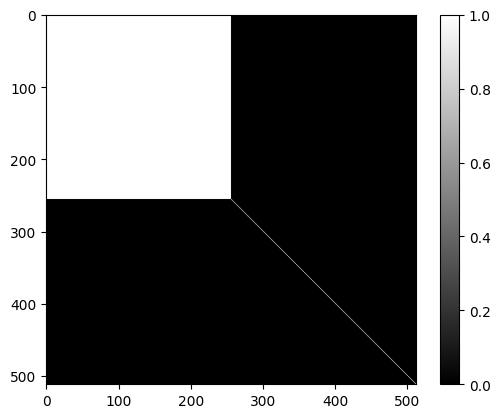

In [15]:
import matplotlib.pyplot as plt
from probjax.nn.pallas_kernels.attention_mask_bias import CausalMask, materialize_mask, LocalWindowMask, SameSegmentMask, KeyPaddingMask, QKVLengthMask, MarginalizationMask, SeqLenMask

mask = CausalMask()
mask = LocalWindowMask(32,32)
segment_id = jnp.arange(seq_len)
mask = SameSegmentMask(segment_id, segment_id[::-1])
mask = KeyPaddingMask(jnp.array([256]*256 + [64]*128 + [32]*128))
mask = QKVLengthMask(q_length=50, kv_length=210, block_sparse=False)
mask = jax.random.bernoulli(jax.random.PRNGKey(0), p=0.5, shape=(seq_len,))
mask = QKVLengthMask(512,512) & MarginalizationMask(mask)
mask = SeqLenMask(jnp.array([256, 128]))

plt.imshow(materialize_mask(mask, 512, 512)[0], cmap='gray', vmin=0, vmax=1)
plt.colorbar()

In [16]:
from probjax.nn.pallas_kernels.attention_mask_bias import DenseBias

bias_dense = jax.random.normal(jax.random.PRNGKey(0), (1,1,seq_len, seq_len)) * 10
bias = DenseBias(bias_dense)

out1 = nnx.dot_product_attention(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), bias=bias_dense)
out2 = flex_attention(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), bias=bias)

In [17]:
q= q.repeat(2, axis=0)[:,:128]
k= k.repeat(2, axis=0)[:,:128]
v= v.repeat(2, axis=0)[:,:128]


In [33]:
q.shape

(2, 128, 8, 64)

In [34]:
mask = SeqLenMask(jnp.array([32, 64]))

In [35]:
mask_dense = materialize_mask(mask, 128, 128)
mask_dense.shape

(2, 128, 128)

In [37]:
out = nnx.dot_product_attention(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), mask=mask_dense[:, None, :,:])
out2 = flex_attention(q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), mask=mask)


In [40]:
float(jnp.max(jnp.abs(out - out2)))

4.76837158203125e-07

In [42]:
q.shape

(2, 128, 8, 64)

In [44]:
seq_len = 128
def loss_fn1(q):
    out = dot_product_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=mask_dense[:, None, :,:])
    return jnp.sum((out-1)**2)
def loss_fn2(q):
    out = flex_attention(q.astype(jnp.float32),k.astype(jnp.float32),v.astype(jnp.float32), mask=mask)
    return jnp.sum((out-1)**2)

grad1 = jax.grad(loss_fn1)(q)
grad2 = jax.grad(loss_fn2)(q)

In [46]:
grad1.shape

(2, 128, 8, 64)

In [47]:
grad1[1,:,0,0] - grad2[1, :,0,0]

Array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       3.57628e-07, -4.4331e-07, -4.19095e-08, 1.03563e-06, 0, 0,
       -1.2219e-06, 0, -1.08778e-06, 0, 2.39909e-06, -3.72529e-06, 0,
       2.39909e-06, -9.98378e-07, 0, -2.36928e-06, 0, 0, -4.19095e-07, 0,
       0, -8.3819e-07, 0, 0, -7.03149e-08, 0, -2.01166e-06, -1.19954e-06,
       -7.1153e-07, 6.25849e-07, -2.34693e-07, 0, 1.03563e-06,
       9.12696e-07, 0, -3.98606e-07, 2.99513e-06, 2.30037e-07, 0,
       -2.14204e-07, 0, 0, 0, 1.44541e-06, 0, 0, 0, 8.15839e-07, 0,
       -8.3819e-07, -1.37091e-06, 1.08033e-06, 5.81145e-07, 0,
       4.39584e-07, 9.12696e-07, -2.5779e-06, 1.60187e-06, 0, 0, 0,
       -2.74181e-06, -2.17557e-06], dtype=bfloat16)

In [48]:
jnp.allclose(grad1, grad2, atol=1e-2, rtol=1e-2)

Array(True, dtype=bool)

In [ ]:
grad1 - grad2

In [ ]:
grad1 - grad2

In [ ]:
from functools import partial


_ = benchmark(attn_fn, q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flex_attention, mask=LocalWindowMask(32,32)))
_ = benchmark(attn_fn, q, k, v)

In [ ]:
attn

In [ ]:
attn_fn = jax.jit(dot_product_attention)
out3 = attn_fn(q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flex_attention, sm_scale=1.))
out = attn_fn(q, k, v)

In [ ]:
attn_fn = jax.jit(partial(flex_attention))
_ = benchmark(attn_fn, q.astype(jnp.float32), k.astype(jnp.float32), v.astype(jnp.float32), CausalMask())

In [113]:
mask = CausalMask()
mask = LocalWindowMask(4,4)
mask = QKVLengthMask(q_length=50, kv_length=80, block_sparse=False)
mask = KeyPaddingMask(jnp.array([32]*128))
mask = SeqLenMask(jnp.array([32, 64]))
import math
def f(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    #return flash_attention(q,q,q, interpret=True, softmax_scale=1/math.sqrt(64)).sum(axis=(-2,-1))
    return flex_attention(q,q,q, mask=mask).sum(axis=(-2,-1))

def g(q):
    q = q.repeat(16, axis=-2)
    q = q.repeat(64, axis=-1)
    if mask is not None:
        mask_dense = materialize_mask(mask, q.shape[-3], q.shape[-3])
    else:
        mask_dense = None
    print(mask_dense.shape, q.shape)
    return nnx.dot_product_attention(q, q, q, mask=mask_dense[:, None,:,:]).sum(axis=(-2,-1))


f_grad_jit = jax.jit(jax.grad(f))

In [114]:
q.shape

(2, 128, 8, 64)

In [115]:
seq_len = 64

J = jax.jacobian(f)(q[:,:seq_len,:1, :1].astype(jnp.float32)).reshape((q.shape[0],q.shape[0],seq_len,seq_len))

In [116]:
J2 = jax.jacobian(g)(q[:,:seq_len,:1, :1].astype(jnp.float32)).reshape((q.shape[0],q.shape[0],seq_len,seq_len))

(2, 64, 64) (2, 64, 16, 64)


In [65]:
J.shape

(2, 64, 64)

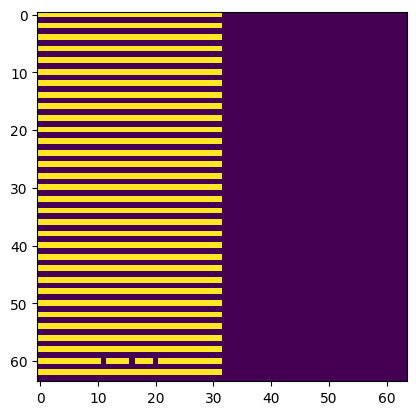

In [121]:
plt.imshow(jnp.abs(J[0,0])> 0,vmin=0, vmax=1)

TypeError: Invalid shape (2, 2, 64, 64) for image data

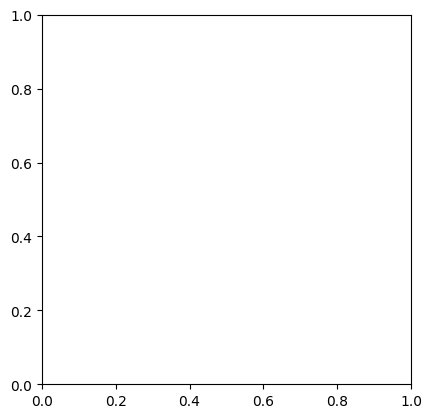

In [119]:
plt.imshow(J - J2, vmin=-0.1, vmax=0.1)
plt.colorbar()

In [ ]:
jnp.abs(J - J2).max()

In [ ]:
plt.imshow(J > 0)
plt.colorbar()

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()

In [ ]:
def f(q):
    return attn_fn(q,q.repeat(2, axis=1),q.repeat(2, axis=1)).sum()


f_grad_jit = jax.jit(jax.grad(f))

In [ ]:
%%timeit
f_grad_jit(q).block_until_ready()